# CRISP-DM Phase 4: Modeling & evaluation (Hospital regression)

## Business framing: AI prescribing assistant
Target: **`Duration (days)`** (continuous). The notebooks **`02b` → this file** build features, compare models on a hold-out set, **diagnose the champion** (errors by duration band, residuals, importances), then export artifacts.

**Governance:** Same `Path` resolution as **`02b`**; reads prep `metadata.json`. **Five-supervisor** checklist is in **§6** before export.

Because we predict a number of days, this is **regression** (not classification).


In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 1. Load Processed Data
We load the heavily engineered matrices (TF-IDF NLP features, Log scales, One-Hot encodings) straight from Phase 3.

In [2]:
candidate_roots = [Path.cwd(), Path.cwd() / 'regression_hospital_data _set']
base_dir = next((r for r in candidate_roots if (r / 'data' / 'processed' / 'hospital' / 'X_train.csv').exists()), None)
if base_dir is None:
    raise FileNotFoundError(
        'Processed hospital CSVs not found; run 02b_DataPreparation_Hospital.ipynb first '
        '(from repo root or regression_hospital_data _set/).'
    )

data_dir = base_dir / 'data' / 'processed' / 'hospital'

X_train = pd.read_csv(data_dir / 'X_train.csv')
X_test = pd.read_csv(data_dir / 'X_test.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze()
y_test = pd.read_csv(data_dir / 'y_test.csv').squeeze()

prep_meta = json.loads((data_dir / 'metadata.json').read_text(encoding='utf-8'))
print('Prep metadata: random_state =', prep_meta.get('random_state'), '| split =', prep_meta.get('train_test_split'))
print(f'Train {X_train.shape} | Test {X_test.shape}')
if list(X_train.columns) != prep_meta.get('X_train_columns'):
    print('Warning: feature columns differ from prep metadata (expected after changing prep).')


Prep metadata: random_state = 42 | split = random_80_20
Train (659, 53) | Test (165, 53)


## 2. Model initialization
We compare a **median dummy** baseline, **ordinary least squares**, **Ridge**, **SVR (RBF) inside a pipeline with sparse-safe scaling**, and two tree ensembles (**Random Forest**, **Gradient Boosting**). The dummy answers: “Does any model beat predicting the training median?”

In [3]:
# SVR: scale sparse-friendly (with_mean=False) for TF-IDF columns mixed with numeric.
models = {
    'Dummy (median baseline)': DummyRegressor(strategy='median'),
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1.0),
    'SVR (RBF, scaled)': make_pipeline(StandardScaler(with_mean=False), SVR(kernel='rbf')),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}


## 3. Training & evaluation
Metrics (all on **duration in days**):
- **RMSE (test):** Penalizes large errors; same units as the target.
- **MAE (test):** Typical absolute error in days; often easier to explain to stakeholders.
- **R² (test):** Fraction of variance explained on the hold-out set (can be low when signal is noisy).
- **RMSE (train):** Compared to test RMSE to spot **overfitting** (much lower train than test).

In [4]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    p_tr = model.predict(X_train)
    p_te = model.predict(X_test)
    results.append({
        'Model': name,
        'RMSE test (days)': root_mean_squared_error(y_test, p_te),
        'RMSE train (days)': root_mean_squared_error(y_train, p_tr),
        'MAE test (days)': mean_absolute_error(y_test, p_te),
        'R2 test': r2_score(y_test, p_te),
    })

benchmarks = pd.DataFrame(results).sort_values('RMSE test (days)').reset_index(drop=True)
display(benchmarks)
champ_row = benchmarks.iloc[0]
gap = champ_row['RMSE train (days)'] - champ_row['RMSE test (days)']
print(
    f"Champion (test RMSE): {champ_row['Model']} | "
    f"train minus test RMSE = {gap:.3f} "
    f"(negative => train fits tighter than test; check overfitting)"
)


,Model,RMSE test (days),RMSE train (days),MAE test (days),R2 test
0,Random Forest,3.013601,0.740379,1.610343,0.302829
1,Gradient Boosting,3.070089,1.760546,1.949038,0.276448
2,Linear Regression,3.266392,2.479303,2.256972,0.180961
3,Ridge (alpha=1),3.289286,2.482796,2.267658,0.169440
4,"SVR (RBF, scaled)",3.454881,2.345500,2.190577,0.083707
5,Dummy (median baseline),3.761850,2.918727,2.527273,-0.086353


Champion (test RMSE): Random Forest | train minus test RMSE = -2.273 (negative => train fits tighter than test; check overfitting)


## 4. Model comparison (hold-out RMSE)

Bar chart ranks models by **test RMSE** (dummy baseline omitted from the chart so the scale is readable).


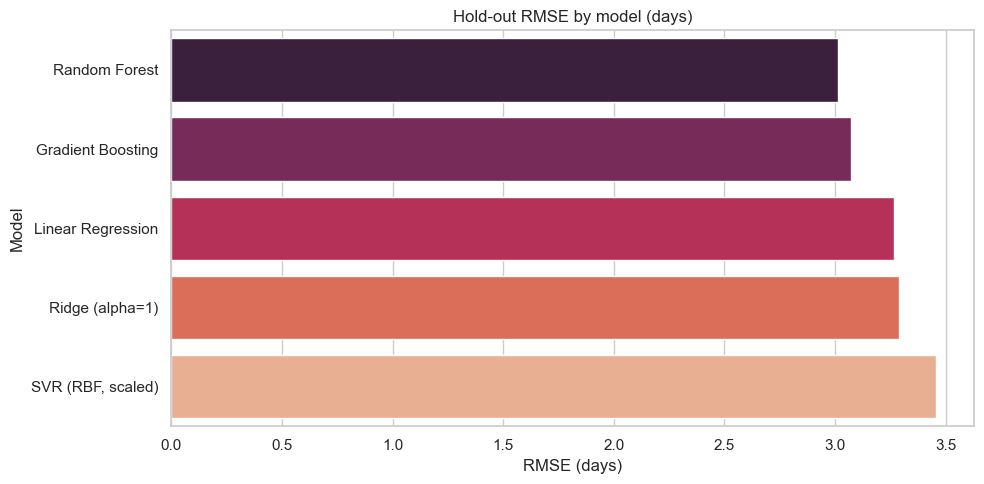

In [5]:
plot_df = benchmarks[benchmarks['Model'] != 'Dummy (median baseline)'].copy()
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='RMSE test (days)', y='Model', palette='rocket')
plt.title('Hold-out RMSE by model (days)')
plt.xlabel('RMSE (days)')
plt.tight_layout()
plt.show()


## 5. Champion deep-dive (same test set)

Uses the **lowest test-RMSE** model (`champ_row`), falling back to the next model only if the dummy somehow wins (should not happen here).

Diagnostics: **predicted vs actual**, **residual histogram**, **absolute error by duration band**, **residuals vs predicted**, and **feature importances** when the champion exposes `feature_importances_` (e.g. Random Forest).


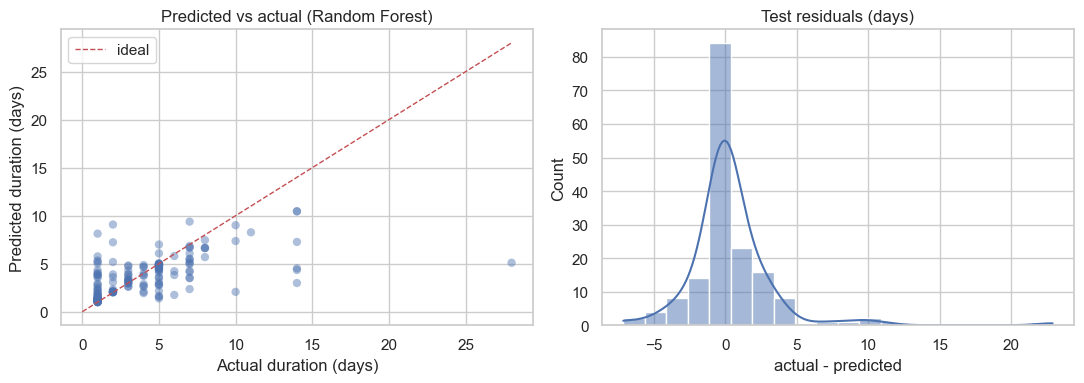

In [6]:
rank_name = champ_row['Model']
if rank_name == 'Dummy (median baseline)' and len(benchmarks) > 1:
    rank_name = benchmarks.iloc[1]['Model']
champ = trained_models[rank_name]
y_hat = champ.predict(X_test)
yt = np.asarray(y_test).ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(yt, y_hat, alpha=0.45, edgecolors='none')
mx = float(max(yt.max(), y_hat.max()))
axes[0].plot([0, mx], [0, mx], 'r--', lw=1, label='ideal')
axes[0].set_xlabel('Actual duration (days)')
axes[0].set_ylabel('Predicted duration (days)')
axes[0].set_title(f'Predicted vs actual ({rank_name})')
axes[0].legend()
sns.histplot(yt - y_hat, bins=20, kde=True, ax=axes[1])
axes[1].set_title('Test residuals (days)')
axes[1].set_xlabel('actual - predicted')
plt.tight_layout()
plt.show()


### 5b. Error by duration band

Bucket **actual** duration to see whether errors grow for longer courses.


,mean,median,count
band,,,
0-2d,1.235,0.370,69
2-5d,0.883,0.500,61
5-10d,2.111,1.780,27
10d+,8.698,8.105,8


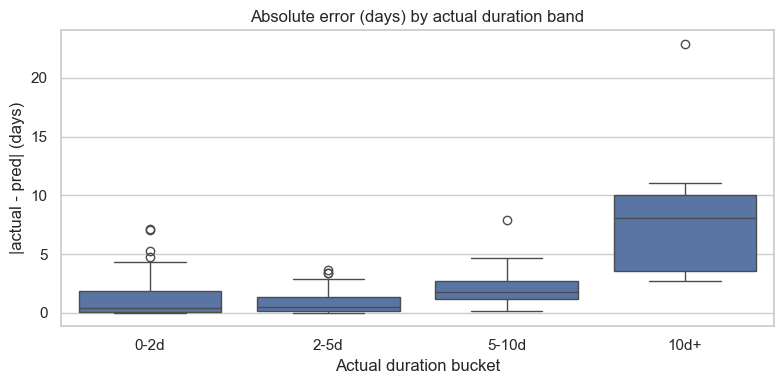

In [7]:
df_ev = pd.DataFrame({'actual': yt, 'pred': y_hat, 'abs_err': np.abs(yt - y_hat)})
df_ev['band'] = pd.cut(
    df_ev['actual'],
    bins=[0, 2, 5, 10, 100],
    labels=['0-2d', '2-5d', '5-10d', '10d+'],
    include_lowest=True,
)
band_stats = df_ev.groupby('band', observed=False)['abs_err'].agg(['mean', 'median', 'count']).round(3)
display(band_stats)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_ev, x='band', y='abs_err')
plt.title('Absolute error (days) by actual duration band')
plt.xlabel('Actual duration bucket')
plt.ylabel('|actual - pred| (days)')
plt.tight_layout()
plt.show()


### 5c. Residuals vs predicted

Useful to spot **heteroscedasticity** (error spread changing with prediction level).


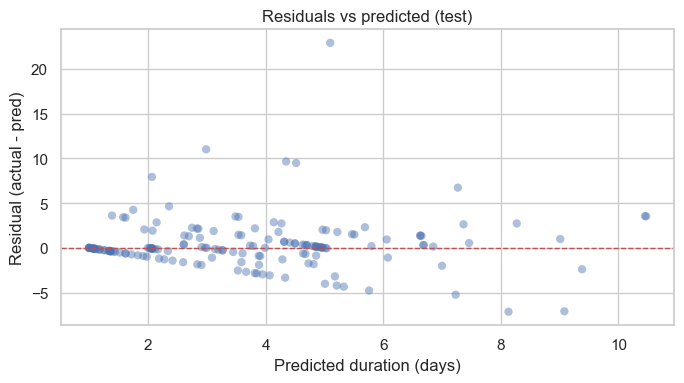

In [8]:
res = yt - y_hat
plt.figure(figsize=(7, 4))
plt.scatter(y_hat, res, alpha=0.45, edgecolors='none')
plt.axhline(0, color='r', linestyle='--', linewidth=1)
plt.xlabel('Predicted duration (days)')
plt.ylabel('Residual (actual - pred)')
plt.title('Residuals vs predicted (test)')
plt.tight_layout()
plt.show()


### 5d. Feature importance (tree champions only)

Skipped automatically if the champion has no `feature_importances_`.


,feature,importance
1,Scaled_Age,0.226837
0,Log_Dosage,0.077298
25,Name of Drug_amoxiclav,0.063832
14,Diagnosis_dm,0.056273
15,Diagnosis_hypertension,0.041979
31,Name of Drug_clarithromycin,0.038828
12,Diagnosis_col,0.037170
10,Diagnosis_chest,0.027020
34,Name of Drug_levofloxacin,0.026153
19,Diagnosis_lung,0.023146


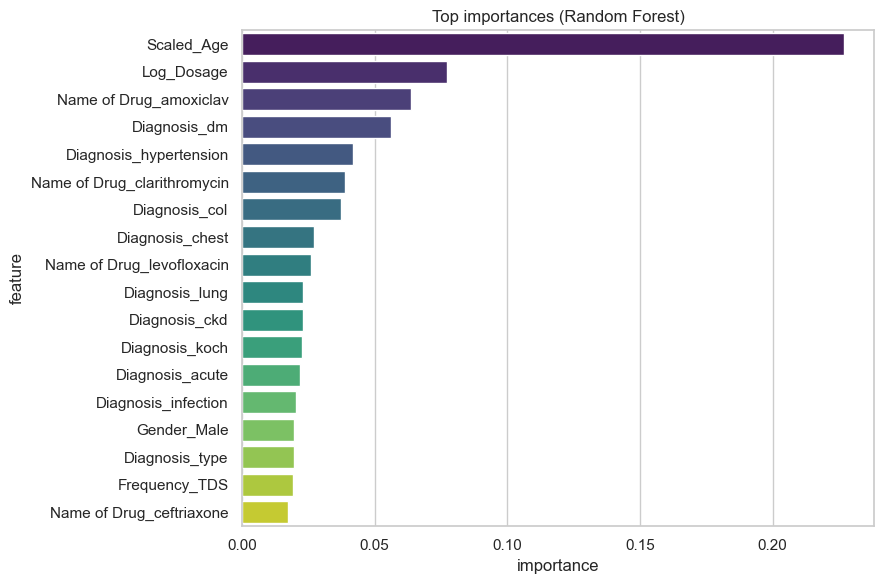

In [9]:
feat_names = list(X_train.columns)
imp = getattr(champ, 'feature_importances_', None)
if imp is not None:
    fi = (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False)
        .head(18)
    )
    display(fi)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=fi, y='feature', x='importance', palette='viridis')
    plt.title(f'Top importances ({rank_name})')
    plt.tight_layout()
    plt.show()
else:
    print('Champion has no feature_importances_; skip or use permutation_importance in a future iteration.')


## 6. Five-supervisor sign-off (modeling + evaluation)

| Role | Focus | Questions |
|------|--------|-----------|
| **1 — Data analysis** | Metrics | Are RMSE / MAE in **days** acceptable for decision-support (not autonomous dosing)? |
| **2 — Data analysis** | Errors by band | Much worse errors in some duration buckets? Residuals biased? |
| **3 — ML** | Baselines & generalization | Beat **median dummy**? Large **train vs test RMSE** gap (overfitting)? |
| **4 — ML** | Model & features | Pipelined **SVR** fair? Do **importances** (if tree) match clinical intuition? |
| **5 — MLOps** | Artifacts | `hospital_duration_model.pkl`, `modeling_metadata.json`, `evaluation_report.json`, and prep `metadata.json` versioned together? |

**Reminder:** Outputs are **associational**, not causal; not a substitute for clinical protocols.


## 7. Deployment export

Save the **champion** estimator (test-RMSE winner), **modeling metadata**, and a short **evaluation report** for traceability.


In [10]:
best_model_name = champ_row['Model']
if best_model_name == 'Dummy (median baseline)':
    raise ValueError('Champion is the naive median baseline; improve features/models before exporting a pickle.')

best_model = trained_models[best_model_name]
models_dir = base_dir / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
export_path = models_dir / 'hospital_duration_model.pkl'
joblib.dump(best_model, export_path)

mrow = benchmarks.loc[benchmarks['Model'] == best_model_name].iloc[0]
modeling_meta = {
    'notebook': '02c_Modeling_Hospital.ipynb',
    'champion': best_model_name,
    'metrics_test': {
        'rmse_days': float(mrow['RMSE test (days)']),
        'mae_days': float(mrow['MAE test (days)']),
        'r2': float(mrow['R2 test']),
    },
    'metrics_train': {'rmse_days': float(mrow['RMSE train (days)'])},
    'prep_metadata_path': str((data_dir / 'metadata.json').resolve()),
    'n_features': int(X_train.shape[1]),
    'feature_names': list(X_train.columns),
}
(models_dir / 'modeling_metadata.json').write_text(json.dumps(modeling_meta, indent=2), encoding='utf-8')

eval_report = {
    'notebook': '02c_Modeling_Hospital.ipynb',
    'champion': best_model_name,
    'metrics_test': {
        'rmse_days': float(mrow['RMSE test (days)']),
        'mae_days': float(mrow['MAE test (days)']),
        'r2': float(mrow['R2 test']),
    },
    'modeling_metadata_path': str((models_dir / 'modeling_metadata.json').resolve()),
    'n_test': int(len(y_test)),
}
(models_dir / 'evaluation_report.json').write_text(json.dumps(eval_report, indent=2), encoding='utf-8')

print(f'Saved: {export_path.resolve()}')
print(f'Saved: {(models_dir / "modeling_metadata.json").resolve()}')
print(f'Saved: {(models_dir / "evaluation_report.json").resolve()}')


Saved: C:\Users\rahma\Desktop\machine learning project\regression_hospital_data _set\models\hospital_duration_model.pkl
Saved: C:\Users\rahma\Desktop\machine learning project\regression_hospital_data _set\models\modeling_metadata.json
Saved: C:\Users\rahma\Desktop\machine learning project\regression_hospital_data _set\models\evaluation_report.json


In [11]:
# end of notebook
